In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import pickle as pk
import os, sys

from sklearn.metrics import roc_auc_score

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("./"), os.pardir)))
from customFunctions.utils import binary_auROC

In [2]:
# from CustomEstimators.DataFrameUtils import *
# from CustomEstimators.PartialPCA import PartialPCA
# from CustomEstimators.FilterByCorrelation import FilterByCorrelation
# from CustomEstimators.GridSearchOOB_BinaryClassifier import GridSearchOOB_BinaryClassifier



# def binary_auROC(clf, input_data, binary_target):
#     return roc_auc_score(binary_target, clf.predict_proba(input_data)[:,1])

In [3]:
y_train = pd.read_csv("data/training_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["benign", "pathogenic"], [0,1])
X = pd.read_csv("checkpoints/mithril_features.csv", sep="\t", index_col=0)
X.shape

/tmp/ipykernel_3698922/2333401321.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["benign", "pathogenic"], [0,1])


(4521, 20)

In [4]:
embedding = pd.read_csv("data/Mithril_msm_embedding.csv", index_col=0)
embedding.index.name = "Mithril_id"
embedding.columns = "channel_"+embedding.columns.astype(str)
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,-0.046571,-0.464829,-1.071173,0.706031,0.254538,-0.839300,-0.785148,-0.686940,-0.066750,-0.083101,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,-0.094558,-0.843313,-0.774938,0.836958,-0.283595,-0.961378,-0.578084,-0.701949,0.039039,-0.158005,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,0.050315,-0.794720,-0.958813,0.551639,-0.071321,-0.767290,-0.558026,-0.843187,0.249865,-0.380568,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,-0.271729,-0.401465,-0.722368,0.715860,-0.171587,-0.678559,-0.540892,-0.339579,-0.256668,-0.268223,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,-0.189935,-0.290123,-0.115013,0.859563,-0.127386,-0.715655,-0.411798,-0.926073,-0.151554,-0.170612,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.085203,0.720789,0.258117,-0.241561,0.276256,0.001175,0.117050,-0.357717,0.238088,0.165467,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,-0.516000,0.442102,0.331330,0.229251,-0.081880,-0.531516,0.226194,-0.564276,0.209845,-0.133919,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,0.318094,0.357954,-0.837745,-0.545639,-0.157910,0.394076,-1.226594,-0.005673,0.406269,-0.306028,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [5]:
X_extended = X.join(embedding)
X_extended

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [6]:
tuned_model_svc = pk.load(open("checkpoints/candidate_models/model_svc.pk", "rb"))
tuned_model_svc

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x7af4314242c0>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7af4309ffec0>, verbose=2)

In [11]:
tapogee_predictions = pd.Series(
    tuned_model_svc.predict_proba(X_extended)[:,1], index=X.index
).rename("tAPOGEE_score").to_frame()
tapogee_predictions.loc[y_train.index, "tAPOGEE_oob_score"] = tuned_model_svc.best_estimator_[-1]\
    .estimator.oob_decision_function_[:,1]
tapogee_predictions.loc[tapogee_predictions.tAPOGEE_oob_score.isna(), "tAPOGEE_oob_score"] = tapogee_predictions.tAPOGEE_score
tapogee_predictions

,tAPOGEE_score,tAPOGEE_oob_score
Mithril_id,,
MITHRIL.1728,0.780641,0.780641
MITHRIL.1729,0.703568,0.703568
MITHRIL.1730,0.767472,0.767472
MITHRIL.1731,0.520965,0.520965
MITHRIL.1732,0.632326,0.632326
...,...,...
MITHRIL.48239,0.665709,0.665709
MITHRIL.48240,0.773280,0.773280
MITHRIL.48241,0.841406,0.834604


In [12]:
plt.figure(figsize=(5,5))
plt.scatter(
    tapogee_predictions.tAPOGEE_score,
    tapogee_predictions.tAPOGEE_OOB_score,
    c=y_train.reindex(tapogee_predictions.index),
    cmap="RdYlGn_r", alpha=.1
)
plt.plot([0,1],[0,1], c="black", linestyle="--")
plt.show()

AttributeError: 'DataFrame' object has no attribute 'tAPOGEE_OOB_score'

<Figure size 500x500 with 0 Axes>

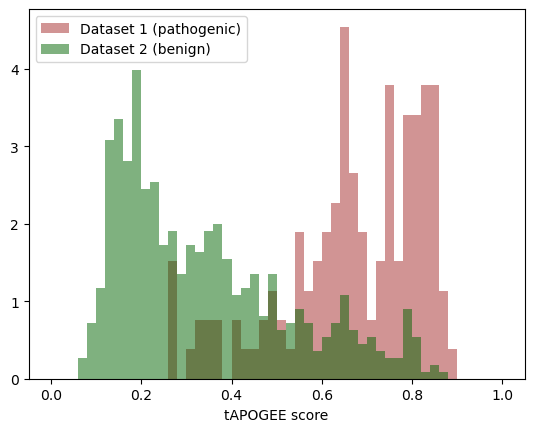

In [13]:
plt.hist(
    tapogee_predictions.tAPOGEE_score.loc[y_train.index[y_train==1]],
    bins=np.linspace(0,1,51), alpha=.5, color="brown", density=True,
    label="Dataset 1 (pathogenic)"
)

plt.hist(
    tapogee_predictions.tAPOGEE_score.loc[y_train.index[y_train==0]],
    bins=np.linspace(0,1,51), alpha=.5, color="darkgreen", density=True,
    label="Dataset 2 (benign)"
)

plt.xlabel("tAPOGEE score")
plt.legend()
plt.show()

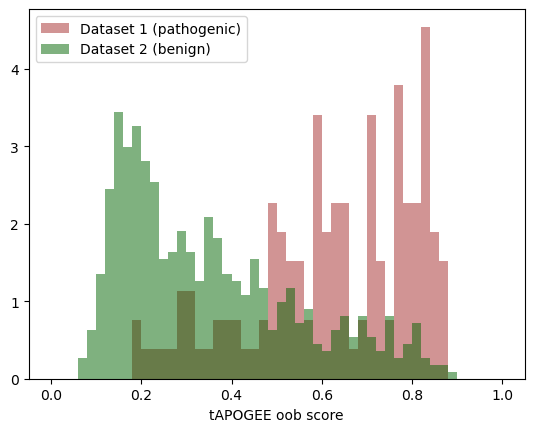

In [15]:
plt.hist(
    tapogee_predictions.tAPOGEE_oob_score.loc[y_train.index[y_train==1]],
    bins=np.linspace(0,1,51), alpha=.5, color="brown", density=True,
    label="Dataset 1 (pathogenic)"
)

plt.hist(
    tapogee_predictions.tAPOGEE_oob_score.loc[y_train.index[y_train==0]],
    bins=np.linspace(0,1,51), alpha=.5, color="darkgreen", density=True,
    label="Dataset 2 (benign)"
)

plt.xlabel("tAPOGEE oob score")
plt.legend()
plt.show()

In [17]:
roc_auc_score(
    y_train, tapogee_predictions.tAPOGEE_oob_score.reindex(y_train.index)
)

np.float64(0.840758124725516)

In [18]:
y_test = pd.read_csv("data/test_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["Benign", "Likely benign", "Pathogenic", "Likely pathogenic"], [0, 0, 1, 1])
y_test

/tmp/ipykernel_3698922/1276231137.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["Benign", "Likely benign", "Pathogenic", "Likely pathogenic"], [0, 0, 1, 1])


Mithril_id
MITHRIL.1846     1
MITHRIL.4929     1
MITHRIL.9729     1
MITHRIL.9728     1
MITHRIL.9752     1
                ..
MITHRIL.17470    0
MITHRIL.17540    0
MITHRIL.30284    0
MITHRIL.44252    0
MITHRIL.47953    0
Name: label, Length: 71, dtype: int64

In [19]:
roc_auc_score(
    y_test, tapogee_predictions.tAPOGEE_oob_score.reindex(y_test.index)
)

np.float64(0.9338118022328549)

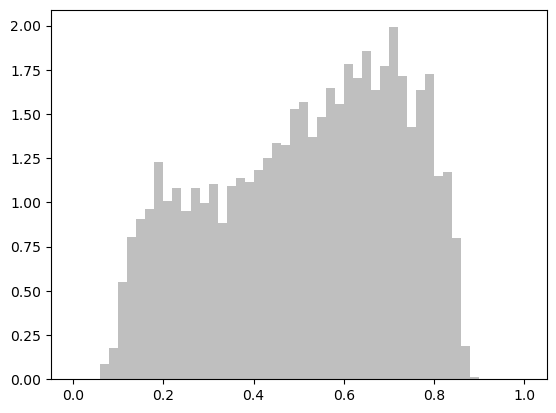

In [20]:
plt.hist(
    tapogee_predictions.tAPOGEE_oob_score, bins=np.linspace(0,1,51),
    alpha=0.5, density=True, color="grey"
)
plt.show()

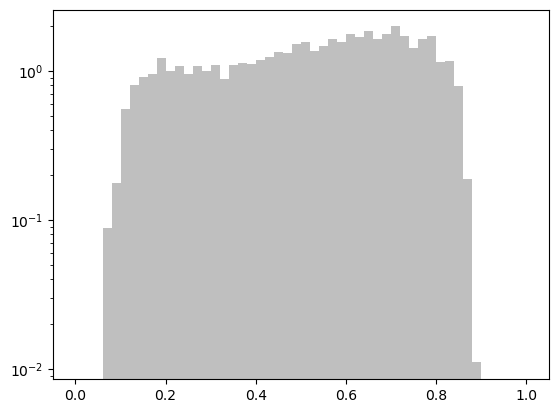

In [21]:
plt.hist(
    tapogee_predictions.tAPOGEE_oob_score, bins=np.linspace(0,1,51),
    alpha=0.5, density=True, color="grey"
)
plt.yscale("log")
plt.show()

In [22]:
from CustomEstimators.ZeroOneInflatedBeta import ZeroOneInflatedBeta

zoib = ZeroOneInflatedBeta()
zoib.fit(tapogee_predictions.tAPOGEE_oob_score)
zoib

/home/saldan/Desktop/projects/nAPOGEE/CustomEstimators/ZeroOneInflatedBeta.py:37: UserWarning: No extremes values have been found. Bernoulli model will not be fitted.
  warnings.warn("No extremes values have been found. Bernoulli model will not be fitted.")


0.00 * Bernoulli(?) + 1.00 * Beta(2.64, 2.51)

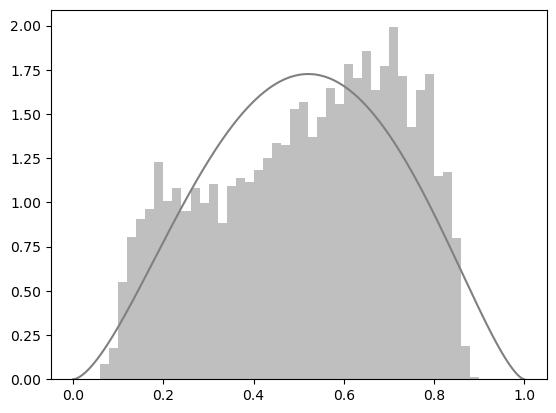

In [23]:
plt.hist(
    tapogee_predictions.tAPOGEE_oob_score, bins=np.linspace(0,1,51),
    alpha=0.5, density=True, color="grey"
)

zoib = ZeroOneInflatedBeta()
zoib.fit(tapogee_predictions.tAPOGEE_oob_score)
plt.plot(
    np.linspace(0,1,1000),
    zoib.pdf(np.linspace(0,1,1000)),
    color="grey"
)

plt.show()

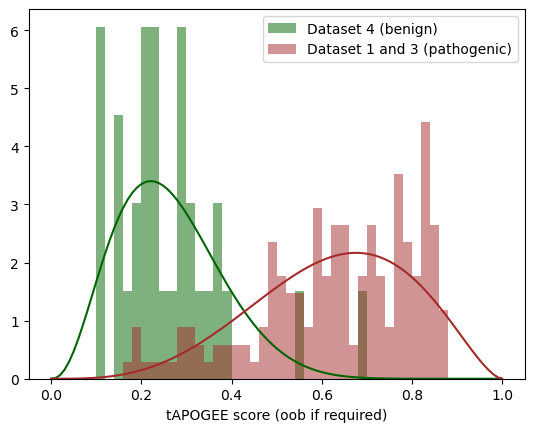

In [28]:
negative_ids = y_test[y_test==0].index
positive_ids = y_test[y_test==1].index.union(y_train[y_train==1].index)

plt.hist(
    tapogee_predictions.loc[negative_ids, "tAPOGEE_oob_score"],
    bins=np.linspace(0,1,51), alpha=0.5, density=True,
    color="darkgreen", label="Dataset 4 (benign)"
)

negative_zoib = ZeroOneInflatedBeta()
negative_zoib.fit(
    tapogee_predictions.loc[negative_ids, "tAPOGEE_oob_score"],
)
plt.plot(
    np.linspace(0,1,101),
    negative_zoib.pdf(np.linspace(0,1,101)),
    color="darkgreen"
)

plt.hist(
    tapogee_predictions.loc[positive_ids, "tAPOGEE_oob_score"],
    bins=np.linspace(0,1,51), alpha=0.5, density=True,
    color="brown", label="Dataset 1 and 3 (pathogenic)"
)
positive_zoib = ZeroOneInflatedBeta()
positive_zoib.fit(
    tapogee_predictions.loc[positive_ids, "tAPOGEE_oob_score"],
)
plt.plot(
    np.linspace(0,1,101),
    positive_zoib.pdf(np.linspace(0,1,101)),
    color="brown"
)

plt.xlabel("tAPOGEE score (oob if required)")
plt.legend()
plt.show()

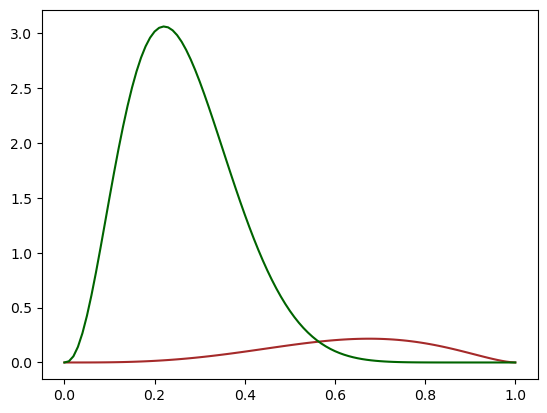

In [29]:
plt.plot(
    np.linspace(0,1,101),
    positive_zoib.pdf(np.linspace(0,1,101))*.1,
    color="brown"
)
plt.plot(
    np.linspace(0,1,101),
    negative_zoib.pdf(np.linspace(0,1,101))*.9,
    color="darkgreen"
)

/tmp/ipykernel_3698922/8866705.py:7: RuntimeWarning: invalid value encountered in divide
  posterior = (likelyhood_positive * prior) / (likelyhood_positive * prior + likelyhood_negative * (1 - prior))


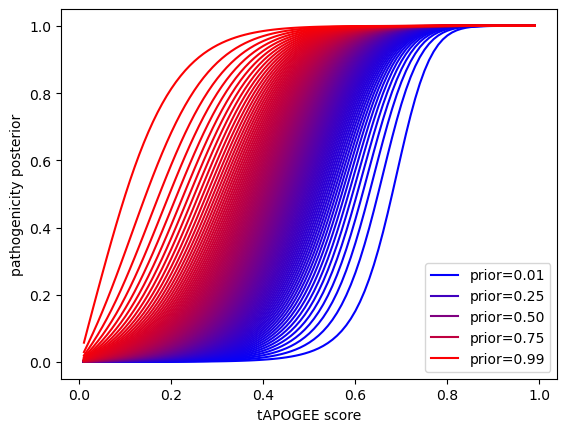

In [38]:
def posterior_proba(score, prior=0.10):
    # Positive and negative likelihoods (given the score)
    likelyhood_positive = positive_zoib.pdf(score)
    likelyhood_negative = negative_zoib.pdf(score)
    
    # Compute the posterior probability using Bayes' theorem
    posterior = (likelyhood_positive * prior) / (likelyhood_positive * prior + likelyhood_negative * (1 - prior))
    return posterior

for prior in np.linspace(0.01,0.99,99):
    plt.plot(
        np.linspace(0,1,101), posterior_proba(np.linspace(0,1,101), prior),
        color=(prior, 0, 1-prior)
    )
    if prior in [0.01, .25, .5, .75, 0.99]:
        plt.plot([], [], color=(prior, 0, 1-prior), label=f"prior={prior:.2f}")

plt.xlabel("tAPOGEE score")
plt.ylabel("pathogenicity posterior")
plt.legend()
plt.show()

/tmp/ipykernel_3698922/8866705.py:7: RuntimeWarning: invalid value encountered in divide
  posterior = (likelyhood_positive * prior) / (likelyhood_positive * prior + likelyhood_negative * (1 - prior))


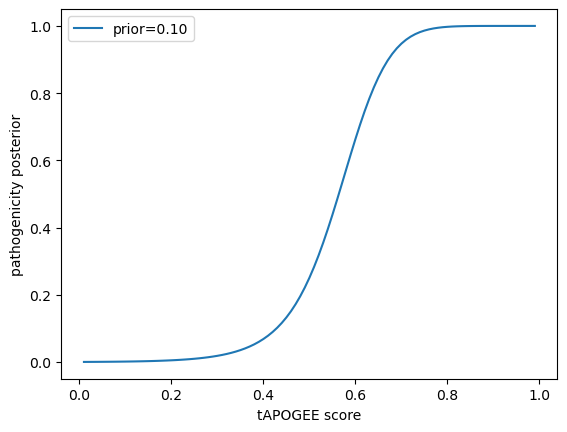

In [41]:
plt.plot(
    np.linspace(0,1,101), posterior_proba(np.linspace(0,1,101), 0.1),
    label="prior=0.10"
)
plt.xlabel("tAPOGEE score")
plt.ylabel("pathogenicity posterior")
plt.legend()
plt.show()

In [42]:
tapogee_predictions["tAPOGEE_posterior"] = posterior_proba(tapogee_predictions.tAPOGEE_oob_score)
tapogee_predictions["category"] = pd.cut(
    tapogee_predictions.tAPOGEE_posterior, bins=[0., 0.001, 0.1, 0.9, 0.99, 1],
    labels=["benign", "likely benign", "VUS", "likely pathogenic", "pathogenic"],
    include_lowest=True
)
tapogee_predictions

,tAPOGEE_score,tAPOGEE_oob_score,tAPOGEE_posterior,category
Mithril_id,,,,
MITHRIL.1728,0.780641,0.780641,0.994751,pathogenic
MITHRIL.1729,0.703568,0.703568,0.951709,likely pathogenic
MITHRIL.1730,0.767472,0.767472,0.991911,pathogenic
MITHRIL.1731,0.520965,0.520965,0.320783,VUS
MITHRIL.1732,0.632326,0.632326,0.791225,VUS
...,...,...,...,...
MITHRIL.48239,0.665709,0.665709,0.887440,VUS
MITHRIL.48240,0.773280,0.773280,0.993295,pathogenic
MITHRIL.48241,0.841406,0.834604,0.999351,pathogenic


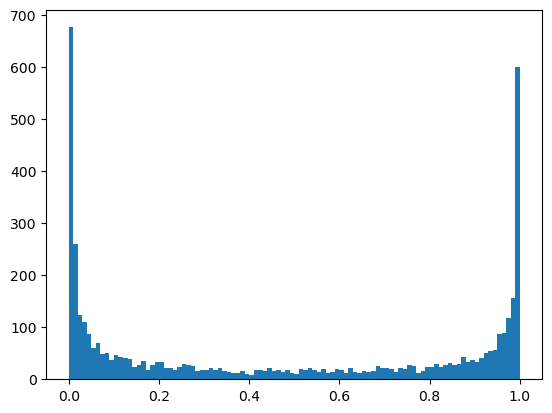

In [43]:
plt.hist(tapogee_predictions.tAPOGEE_posterior, bins=np.linspace(0,1,101))
plt.show()

In [44]:
tapogee_predictions.min(), tapogee_predictions.max()

(tAPOGEE_score         0.06653
 tAPOGEE_oob_score     0.06653
 tAPOGEE_posterior    0.000589
 category               benign
 dtype: object,
 tAPOGEE_score          0.882932
 tAPOGEE_oob_score      0.883694
 tAPOGEE_posterior      0.999951
 category             pathogenic
 dtype: object)

In [45]:
tapogee_predictions.to_csv("checkpoints/tAPOGEE_predictions.csv", sep="\t")

In [46]:
######################################################
############### MISCLASSIFICATION RATE ###############
######################################################

In [47]:
clingen_label = pd.read_csv("data/test_set.txt", sep="\t", index_col="Mithril_id").label
clingen_label

Mithril_id
MITHRIL.1846     Likely pathogenic
MITHRIL.4929     Likely pathogenic
MITHRIL.9729     Likely pathogenic
MITHRIL.9728            Pathogenic
MITHRIL.9752     Likely pathogenic
                       ...        
MITHRIL.17470        Likely benign
MITHRIL.17540        Likely benign
MITHRIL.30284        Likely benign
MITHRIL.44252        Likely benign
MITHRIL.47953        Likely benign
Name: label, Length: 71, dtype: object

In [49]:
confusion_matrix = tapogee_predictions.loc[clingen_label.index].groupby(clingen_label).apply(
    lambda x: x.category.groupby(x.category).size()
)
confusion_matrix

/tmp/ipykernel_3698922/1643808920.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lambda x: x.category.groupby(x.category).size()
/tmp/ipykernel_3698922/1643808920.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lambda x: x.category.groupby(x.category).size()
/tmp/ipykernel_3698922/1643808920.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lambda x: x.category.groupby(x.category).size()
/tmp/ipykernel_3698922

category,benign,likely benign,VUS,likely pathogenic,pathogenic
label,,,,,
Benign,0,19,1,0,0
Likely benign,0,12,0,1,0
Likely pathogenic,0,2,15,7,10
Pathogenic,0,1,1,2,0


/tmp/ipykernel_3698922/285609462.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


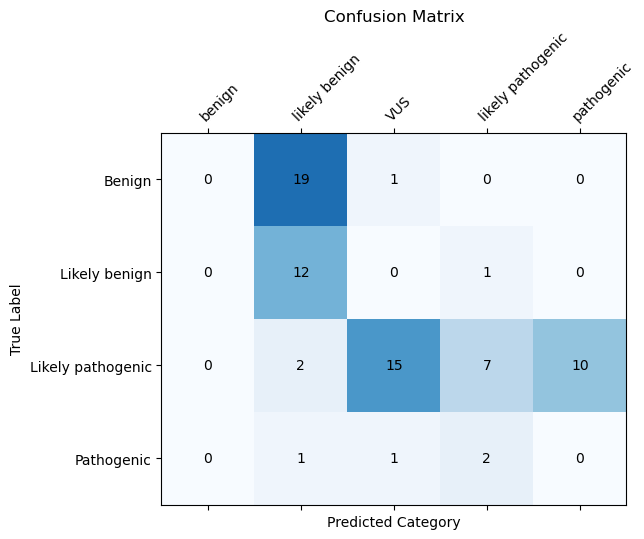

In [50]:
plt.matshow(confusion_matrix, cmap="Blues", vmin=0, vmax=25)

# Show values in the cells
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        value = confusion_matrix.iloc[i, j]
        plt.text(j, i, str(value), ha="center", va="center", color="black")

# pltis formatting
plt.xticks(np.arange(confusion_matrix.shape[1]), confusion_matrix.columns, rotation=45, ha="left", rotation_mode="anchor")
plt.yticks(np.arange(confusion_matrix.shape[0]), confusion_matrix.index)

plt.xlabel("Predicted Category")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

#plt.colorbar(im, plt=plt, label="Count")
plt.tight_layout()
plt.show()

In [51]:
colors = plt.get_cmap("RdYlGn_r")(np.linspace(0, 1, tapogee_predictions.category.nunique()))
colors

array([[0.        , 0.40784314, 0.21568627, 1.        ],
       [0.52795079, 0.79715494, 0.40222991, 1.        ],
       [0.99992311, 0.9976163 , 0.74502115, 1.        ],
       [0.97347174, 0.54740484, 0.31810842, 1.        ],
       [0.64705882, 0.        , 0.14901961, 1.        ]])

In [52]:
train_conf_matrix = pd.concat([
    tapogee_predictions.loc[y_train[y_train==0].index].groupby("category", observed=False).size(),
    tapogee_predictions.loc[y_train[y_train==1].index].groupby("category", observed=False).size()
], axis=1).T
train_conf_matrix = train_conf_matrix.div(train_conf_matrix.sum(axis=1), axis=0)
train_conf_matrix

category,benign,likely benign,VUS,likely pathogenic,pathogenic
0,0.012681,0.673913,0.217391,0.052536,0.043478
1,0.000000,0.151515,0.386364,0.136364,0.325758


In [53]:
test_conf_matrix = pd.concat([
    tapogee_predictions.loc[y_test[y_test==0].index].groupby("category", observed=False).size(),
    tapogee_predictions.loc[y_test[y_test==1].index].groupby("category", observed=False).size()
], axis=1).T
test_conf_matrix = test_conf_matrix.div(test_conf_matrix.sum(axis=1), axis=0)
test_conf_matrix

category,benign,likely benign,VUS,likely pathogenic,pathogenic
0,0.0,0.939394,0.030303,0.030303,0.000000
1,0.0,0.078947,0.421053,0.236842,0.263158


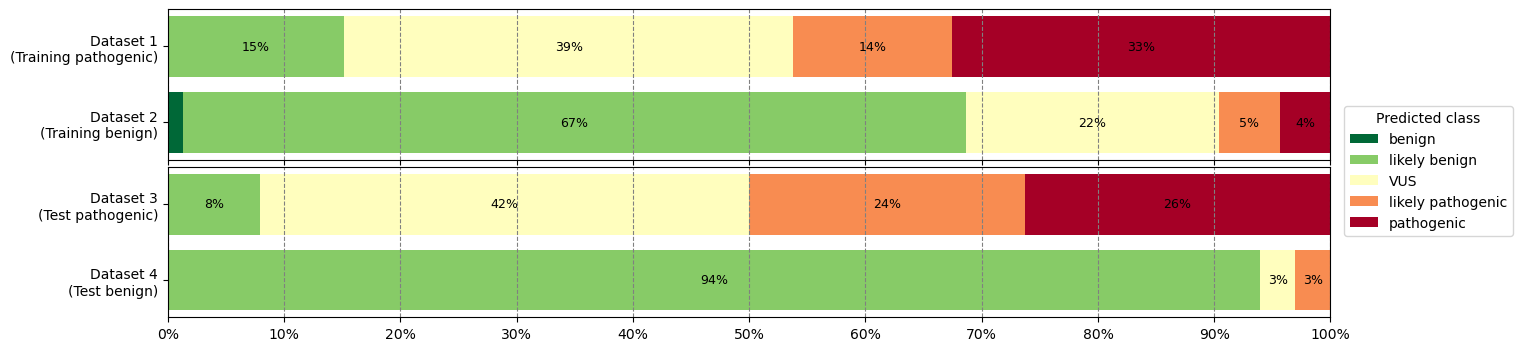

In [54]:
plt.figure(figsize=(15, 4))
plt.subplots_adjust(hspace=0.05)

plt.subplot(2,1,1)
left = np.zeros(len(train_conf_matrix.index))
for i, col in enumerate(train_conf_matrix.columns):
    plt.barh(train_conf_matrix.index, train_conf_matrix[col].values, left=left, color=colors[i], label=col)
    for j, (x, y) in enumerate(zip(left, train_conf_matrix[col].values)):
        if y >= 0.03:  # only label segments wider than 3%
            plt.text(x + y / 2, j, f"{y*100:.0f}%", va='center', ha='center', fontsize=9, color='black')
    left += train_conf_matrix[col].values
plt.xticks(np.linspace(0, 1, 11), ["" for x in np.linspace(0, 1, 11)*100])
plt.yticks(train_conf_matrix.index, ["Dataset 2\n(Training benign)", "Dataset 1\n(Training pathogenic)"])
plt.grid(axis="x", linestyle="--", color="grey")
plt.xlim(0,1)

plt.subplot(2,1,2)
left = np.zeros(len(test_conf_matrix.index))
for i, col in enumerate(test_conf_matrix.columns):
    plt.barh(test_conf_matrix.index, test_conf_matrix[col].values, left=left, color=colors[i], label=col)
    for j, (x, y) in enumerate(zip(left, test_conf_matrix[col].values)):
        if y >= 0.03:  # only label segments wider than 3%
            plt.text(x + y / 2, j, f"{y*100:.0f}%", va='center', ha='center', fontsize=9, color='black')
    left += test_conf_matrix[col].values
plt.xticks(np.linspace(0, 1, 11), [f"{int(x)}%" for x in np.linspace(0, 1, 11)*100])
plt.yticks(test_conf_matrix.index, ["Dataset 4\n(Test benign)", "Dataset 3\n(Test pathogenic)"])
plt.grid(axis="x", linestyle="--", color="grey")
plt.xlim(0,1)

plt.legend(
    bbox_to_anchor=(1, 1.5),  # position to the right
    loc='upper left',
    borderaxespad=1,
    title="Predicted class"
)

plt.show()

In [ ]:
######################################################
################# TODO: move outside  ################
######################################################

In [195]:
mithril_df = pd.read_csv(
    "data/mithril_V03.txt",
    sep="\t", low_memory=False, index_col="Mithril_id", na_values="."
).join(
    (~pd.read_csv("data/PTM_and_domains.txt", sep="\t", index_col=0).modification.isna())\
        .groupby(axis=0, level=0).any()
)
mithril_df = mithril_df.loc[mithril_df["class"]=="tRNA"]
mithril_df = mithril_df.loc[:,~(mithril_df.isna().all())]
mithril_df["aa"] =\
    mithril_df["extended.annotation"].str.split("-").str[-1].str.split(" ").str[0].str.strip()\
    + mithril_df["extended.annotation"].str.split(")", expand=True)[1].str.strip()

# following step is made in order to replicate the mtdb nomenclature:
# - invert Leu1 with Leu2
# - invert Ser1 with Ser2
mithril_df["aa"] = mithril_df.aa.str.replace("2","0").str.replace("1","2").str.replace("0","1")
mithril_df["gene.position"] = mithril_df["gene.position"].astype(int)

mithril_df.drop(['MITHRIL.17488', 'MITHRIL.17489', 'MITHRIL.17490'], axis=0, inplace=True)

mithril_df

,Start,Ref,Alt,class,Gene_symbol,extended.annotation,gene.position,gene.start,gene.end,gene.strand,...,54KJPN_AN,AN_gnomad,AC_hom_gnomad,AC_het_gnomad,AF_hom_gnomad,AF_het_gnomad,FILTER_gnomad,freq_GenBank,modification,aa
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,577,G,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,NaN,56433.0,0.0,0.0,0.000000,0.0,npg,NaN,False,Phe
MITHRIL.1729,577,G,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Phe
MITHRIL.1730,577,G,T,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Phe
MITHRIL.1731,578,T,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Phe
MITHRIL.1732,578,T,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,...,NaN,56433.0,0.0,0.0,0.000000,0.0,npg,NaN,False,Phe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,...,54302.0,56431.0,1.0,0.0,0.000018,0.0,PASS,NaN,False,Pro
MITHRIL.48240,16022,T,G,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Pro
MITHRIL.48241,16023,G,A,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),1,15956,16023,-,...,NaN,56429.0,0.0,0.0,0.000000,0.0,npg,NaN,False,Pro


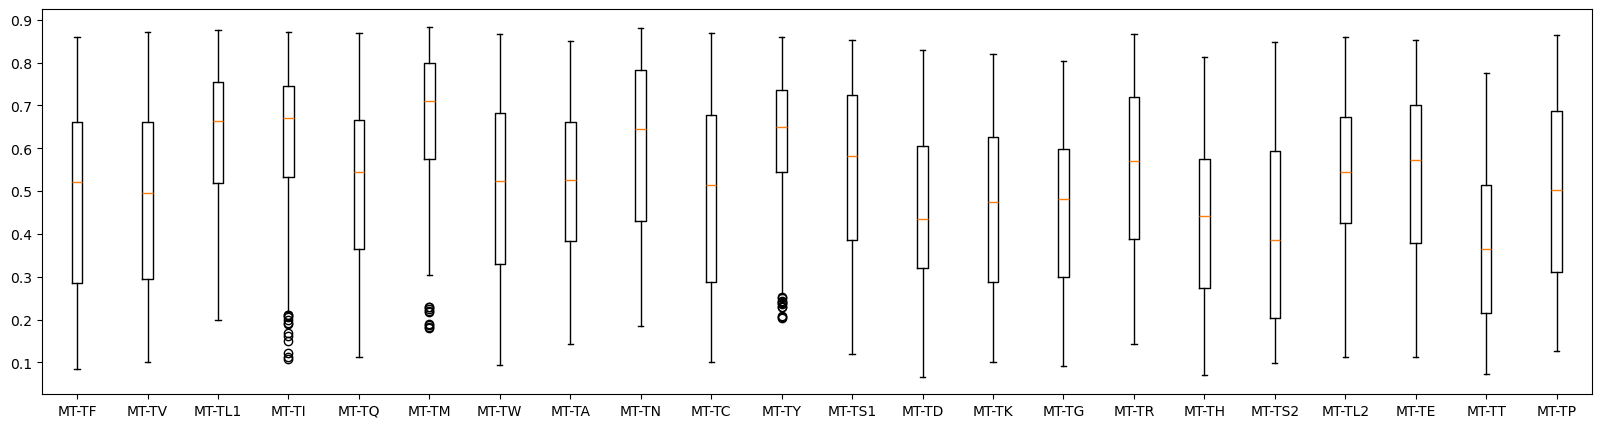

In [ ]:
plt.figure(figsize=(20,5))
for i, gene in enumerate(mithril_df.Gene_symbol.unique()):
    plt.boxplot(
        tapogee_predictions.loc[mithril_df.loc[mithril_df.Gene_symbol==gene].index, "tAPOGEE_oob_score"],
        positions=[i]
    )
plt.xticks(
    np.arange(len(mithril_df.Gene_symbol.unique())),
    mithril_df.Gene_symbol.unique(), rotation=0
)
plt.show()

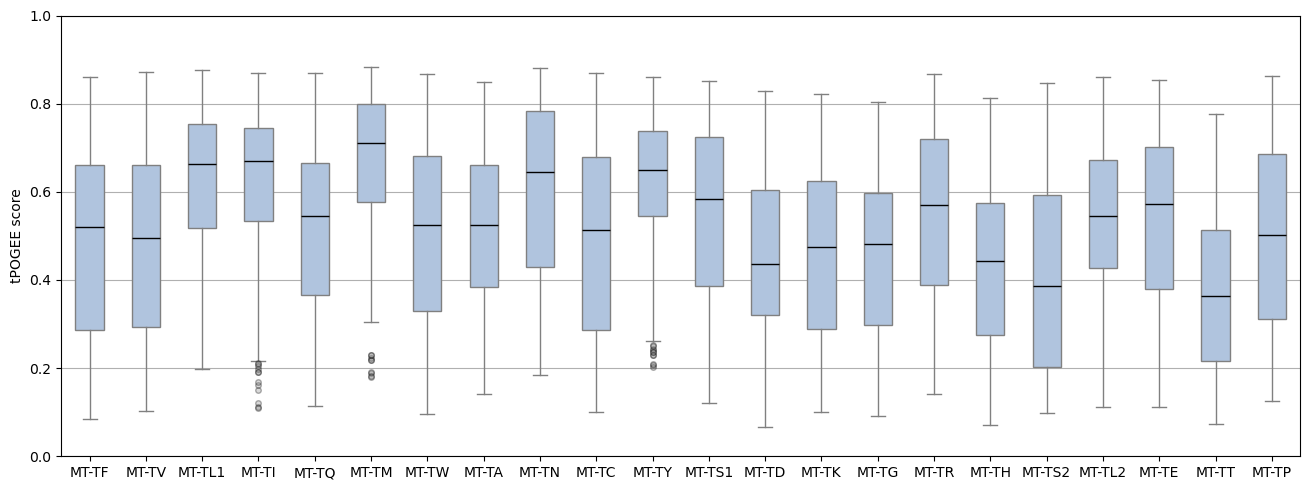

In [ ]:
import matplotlib.pyplot as plt

# Optional: use seaborn for better default style
# plt.style.use("seaborn-whitegrid")

# Get unique genes sorted (optional for consistency)
genes = mithril_df.Gene_symbol.unique()
n_genes = len(genes)

# Set up figure
plt.figure(figsize=(max(12, n_genes * 0.6), 5))  # Adjust width based on number of genes

# Plot all boxplots in a single call (faster and cleaner)
data = [tapogee_predictions.loc[mithril_df[mithril_df.Gene_symbol == gene].index, "tAPOGEE_oob_score"] for gene in genes]

plt.boxplot(data, positions=range(n_genes), patch_artist=True,
            boxprops=dict(facecolor="lightsteelblue", color="gray"),
            medianprops=dict(color="black"),
            whiskerprops=dict(color="gray"),
            capprops=dict(color="gray"),
            flierprops=dict(markerfacecolor='gray', marker='o', markersize=4, linestyle='none', alpha=0.3))

# Format axes
plt.xticks(range(n_genes), genes, rotation=0, ha='center')
plt.ylabel("tAPOGEE score")
plt.ylim(0,1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [26]:
gnomad = pd.read_csv("data/gnomAD_freq.txt", index_col="Mithril_id", sep="\t").gnomad_freq
gnomad

Mithril_id
MITHRIL.1755       1
MITHRIL.1768       1
MITHRIL.1772       1
MITHRIL.1775      10
MITHRIL.1776       3
                ... 
MITHRIL.48174      6
MITHRIL.48176      1
MITHRIL.48197      2
MITHRIL.48224    126
MITHRIL.48239      1
Name: gnomad_freq, Length: 679, dtype: int64

/home/saldan/Desktop/projects/tPOGEE/CustomEstimators/ZeroOneInflatedBeta.py:37: UserWarning: No extremes values have been found. Bernoulli model will not be fitted.
  warnings.warn("No extremes values have been found. Bernoulli model will not be fitted.")


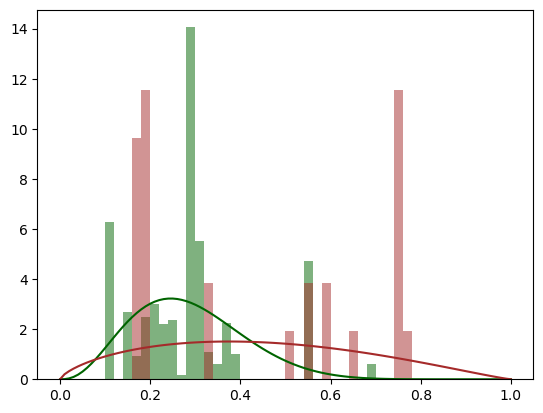

In [ ]:
plt.hist(
    tapogee_predictions.loc[negative_ids, "tAPOGEE_oob_score"].repeat(gnomad.reindex(negative_ids).fillna(0)),
    bins=np.linspace(0,1,51), alpha=0.5, density=True,
    color="darkgreen"
)

negative_zoib = ZeroOneInflatedBeta()
negative_zoib.fit(
    tapogee_predictions.loc[negative_ids, "tAPOGEE_oob_score"].repeat(gnomad.reindex(negative_ids).fillna(0)),
)
plt.plot(
    np.linspace(0,1,101),
    negative_zoib.pdf(np.linspace(0,1,101)),
    color="darkgreen"
)

plt.hist(
    tapogee_predictions.loc[positive_ids, "tAPOGEE_oob_score"].repeat(gnomad.reindex(positive_ids).fillna(0)),
    bins=np.linspace(0,1,51), alpha=0.5, density=True,
    color="brown"
)
positive_zoib = ZeroOneInflatedBeta()
positive_zoib.fit(
    tapogee_predictions.loc[positive_ids, "tAPOGEE_oob_score"].repeat(gnomad.reindex(positive_ids).fillna(0)),
)
plt.plot(
    np.linspace(0,1,101),
    positive_zoib.pdf(np.linspace(0,1,101)),
    color="brown"
)


plt.show()

Mithril_id
MITHRIL.1846     1
MITHRIL.4929     1
MITHRIL.9729     1
MITHRIL.9728     1
MITHRIL.9752     1
                ..
MITHRIL.17470    0
MITHRIL.17540    0
MITHRIL.30284    0
MITHRIL.44252    0
MITHRIL.47953    0
Name: label, Length: 71, dtype: int64